# FinBERT ECB v14 — Full Fix Edition
### Bugs fixed
| # | Bug | Fix |
|---|-----|-----|
| 1 | `F.cross_entropy` ignores class weights | `criterion` (with weights) used in every step |
| 2 | Duplicate `criterion` definitions | Single definition via `compute_class_weight` |
| 3 | `chunk_weight` commented-out / misused | Defined once, applied in loss correctly |
| 4 | Static predictions (majority-class collapse) | Class-weighted loss prevents collapse |
| 5 | Chunk-level ≡ speech-level (single chunk) | `MultiChunkDataset` → many chunks per speech |

### New additions
- `MultiChunkDataset` — overlapping 512-token chunks per speech
- **Gated LM + text fusion** — element-wise gating replaces plain concat
- **Proper AMP training loop** — autocast + GradScaler + gradient clipping
- **Speech-level evaluation** — logit aggregation across all chunks of a speech


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os, gc, re, random, warnings
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
warnings.filterwarnings('ignore')

In [ ]:
import torch, psutil

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    print(f"✅ GPU: {torch.cuda.get_device_name(0)}")
    print(f"   VRAM total : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
    print(f"   VRAM free  : {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated())/1e9:.1f} GB")
else:
    print("⚠️  No GPU — Runtime → Change runtime type → T4 GPU")

ram = psutil.virtual_memory()
print(f"\n💾 RAM total    : {ram.total/1e9:.1f} GB")
print(f"   RAM available: {ram.available/1e9:.1f} GB")

✅ GPU: Tesla T4
   VRAM total : 15.6 GB
   VRAM free  : 15.6 GB

💾 RAM total    : 13.6 GB
   RAM available: 10.3 GB


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from io import StringIO
from collections import defaultdict
from scipy.stats import pearsonr, spearmanr
from torch.amp import autocast, GradScaler

import transformers
transformers.logging.set_verbosity_error()

from transformers import AutoTokenizer, AutoModel, get_cosine_schedule_with_warmup
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, f1_score

device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
AMP_DEVICE = 'cuda' if device.type == 'cuda' else 'cpu'
AMP_DTYPE  = torch.float16 if device.type == 'cuda' else torch.float32

print(f"Device   : {device}")
print(f"AMP dtype: {AMP_DTYPE}")

Device   : cuda
AMP dtype: torch.float16


In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

In [ ]:
url = ("https://data-api.ecb.europa.eu/service/data/YC/"
       "B.U2.EUR.4F.G_N_A.SV_C_YM.SR_10Y"
       "?format=csvdata&startPeriod=1999-01-01")
r = requests.get(url)

lines = r.text.splitlines()
for i, line in enumerate(lines):
    if "TIME_PERIOD" in line:
        header = i
        break

bond = pd.read_csv(StringIO(r.text), skiprows=header)
bond = bond[['TIME_PERIOD', 'OBS_VALUE']]
bond.columns = ['date', 'Bond_Yield']
bond['date']       = pd.to_datetime(bond['date'])
bond['Bond_Yield'] = pd.to_numeric(bond['Bond_Yield'], errors='coerce')
bond = bond.dropna().sort_values('date')
print(f"Bond rows: {len(bond):,}  |  {bond['date'].min().date()} → {bond['date'].max().date()}")
bond.head()

Bond rows: 5,562  |  2004-09-06 → 2026-06-10


,date,Bond_Yield
0,2004-09-06,4.209220
1,2004-09-07,4.209626
2,2004-09-08,4.228419
3,2004-09-09,4.161872
4,2004-09-10,4.120981


In [ ]:
speeches = pd.read_csv('/content/drive/MyDrive/ECB/all_ECB_speeches.csv', sep='|')
speeches['date'] = pd.to_datetime(speeches['date'], errors='coerce')
speeches = speeches.dropna(subset=['date'])
speeches['contents'] = speeches['contents'].astype(str).fillna('')

speeches_daily = speeches.groupby('date')['contents'].apply(' '.join).reset_index()
print(f"Daily speeches: {len(speeches_daily):,}")
speeches_daily.head()

Daily speeches: 2,291


,date,contents
0,1997-02-07,Conference organised by the Hungarian Bankin...
1,1997-03-10,Securing the benefits of EMU Address by Al...
2,1997-04-22,Convergence and the role of the European Cen...
3,1997-04-30,The operation of monetary policy in stage th...
4,1997-05-13,The European Central Bank: independent and a...


In [ ]:
bond['yield_change'] = bond['Bond_Yield'].diff()

df = pd.merge_asof(
    speeches_daily.sort_values('date'),
    bond.sort_values('date'),
    on='date',
    direction='backward',
    tolerance=pd.Timedelta('7D')
).sort_values('date').reset_index(drop=True)

df['yield_change'] = df['Bond_Yield'].diff()
df['volatility']   = df['Bond_Yield'].rolling(5).std()
df['delta_same']   = df['Bond_Yield'].diff(periods=2)
df['delta_next']   = df['Bond_Yield'].shift(-2) - df['Bond_Yield']

upper_thr = df['delta_next'].quantile(0.65)
lower_thr = df['delta_next'].quantile(0.35)

def label(x):
    if x > upper_thr:  return 'UP'
    if x < lower_thr:  return 'DOWN'
    return 'NEUTRAL'

label_map = {'DOWN': 0, 'NEUTRAL': 1, 'UP': 2}
df['label_same'] = df['delta_same'].apply(label).map(label_map)
df['label_next'] = df['delta_next'].apply(label).map(label_map)
df = df.dropna(subset=['label_next']).reset_index(drop=True)

print("Labels distribution:")
print(df['label_next'].value_counts())

Labels distribution:
label_next
1    985
0    653
2    653
Name: count, dtype: int64


In [ ]:
print(df.columns)

Index(['date', 'contents', 'Bond_Yield', 'yield_change', 'volatility',
       'delta_same', 'delta_next', 'label_same', 'label_next'],
      dtype='object')


In [ ]:
LM_DICT_PATH = "/content/drive/MyDrive/ECB/Loughran-McDonald_MasterDictionary_1993-2024.csv"
lm_df = pd.read_csv(LM_DICT_PATH,
                    usecols=['Word','Negative','Positive',
                             'Uncertainty','Strong_Modal','Weak_Modal'])

lm_negative    = set(lm_df[lm_df['Negative']    > 0]['Word'].str.upper())
lm_positive    = set(lm_df[lm_df['Positive']    > 0]['Word'].str.upper())
lm_uncertainty = set(lm_df[lm_df['Uncertainty'] > 0]['Word'].str.upper())
lm_strong_modal= set(lm_df[lm_df['Strong_Modal']> 0]['Word'].str.upper())
lm_weak_modal  = set(lm_df[lm_df['Weak_Modal']  > 0]['Word'].str.upper())
del lm_df; gc.collect()

def compute_lm_features(text):
    words = re.findall(r'[A-Z]+', text.upper())
    n = max(len(words), 1)
    neg  = sum(1 for w in words if w in lm_negative)    / n * 100
    pos  = sum(1 for w in words if w in lm_positive)    / n * 100
    unc  = sum(1 for w in words if w in lm_uncertainty) / n * 100
    strn = sum(1 for w in words if w in lm_strong_modal)/ n * 100
    weak = sum(1 for w in words if w in lm_weak_modal)  / n * 100
    return {
        'lm_negative':       neg,
        'lm_positive':       pos,
        'lm_uncertainty':    unc,
        'lm_net_sentiment':  pos - neg,
        'lm_modal_certainty':strn - weak,
    }

lm_feat_df = pd.DataFrame(df['contents'].astype(str).apply(compute_lm_features).tolist())
df = pd.concat([df, lm_feat_df], axis=1)
print("✅ LM features computed")
print(df[['lm_negative','lm_positive','lm_uncertainty',
          'lm_net_sentiment','lm_modal_certainty']].describe().round(4))

✅ LM features computed
       lm_negative  lm_positive  lm_uncertainty  lm_net_sentiment  \
count    2291.0000    2291.0000       2291.0000         2291.0000   
mean        1.7311       1.3251          1.0652           -0.4061   
std         0.9519       0.6698          0.6475            1.0019   
min         0.0000       0.0000          0.0000           -4.4590   
25%         1.1299       0.9416          0.6802           -1.0479   
50%         1.6958       1.3360          1.0138           -0.3286   
75%         2.3463       1.7380          1.3900            0.2290   
max         5.2470       4.0936          4.5175            2.9126   

       lm_modal_certainty  
count           2291.0000  
mean               0.1085  
std                0.4344  
min               -1.8495  
25%               -0.1216  
50%                0.0413  
75%                0.3026  
max                2.9412  


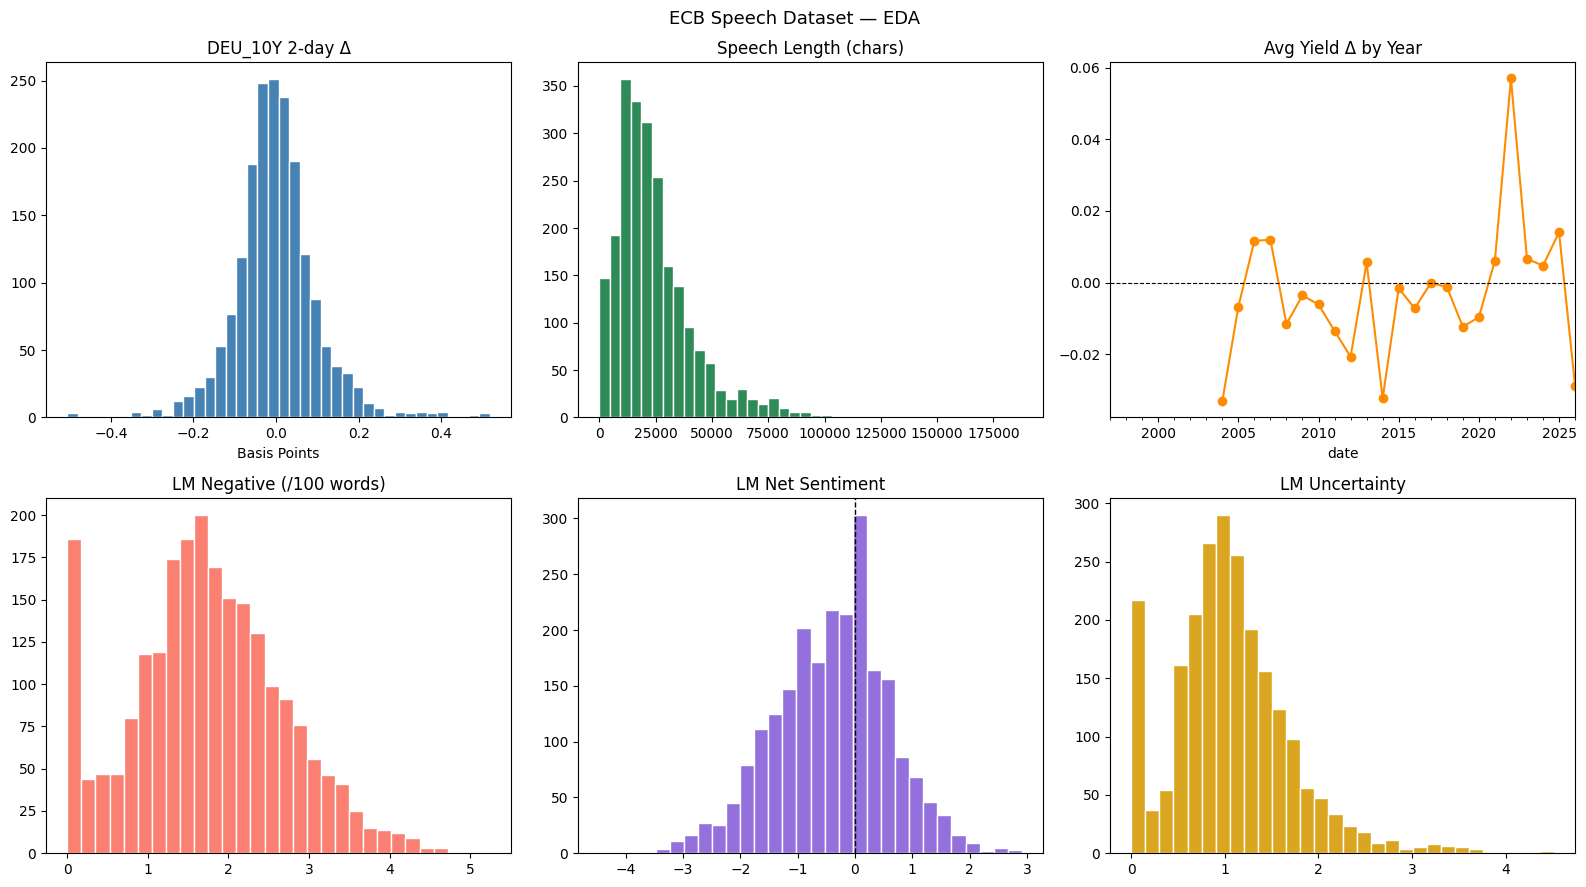

Avg speech: 24473 chars ≈ 5438 tokens
Date range: 1997-02-07 → 2026-02-26


In [ ]:
df['text_len'] = df['contents'].astype(str).str.len()
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

axes[0,0].hist(df['delta_same'].dropna(), bins=40, color='steelblue',  edgecolor='white')
axes[0,0].set_title('DEU_10Y 2-day Δ'); axes[0,0].set_xlabel('Basis Points')

axes[0,1].hist(df['text_len'].dropna(),  bins=40, color='seagreen',   edgecolor='white')
axes[0,1].set_title('Speech Length (chars)')

df.set_index('date')['delta_same'].resample('Y').mean().plot(
    ax=axes[0,2], marker='o', color='darkorange')
axes[0,2].axhline(0, color='black', lw=0.8, ls='--')
axes[0,2].set_title('Avg Yield Δ by Year')

axes[1,0].hist(df['lm_negative'],      bins=30, color='salmon',       edgecolor='white')
axes[1,0].set_title('LM Negative (/100 words)')

axes[1,1].hist(df['lm_net_sentiment'], bins=30, color='mediumpurple', edgecolor='white')
axes[1,1].axvline(0, color='black', lw=1, ls='--'); axes[1,1].set_title('LM Net Sentiment')

axes[1,2].hist(df['lm_uncertainty'],   bins=30, color='goldenrod',    edgecolor='white')
axes[1,2].set_title('LM Uncertainty')

plt.suptitle('ECB Speech Dataset — EDA', fontsize=13)
plt.tight_layout(); plt.show()
print(f"Avg speech: {df['text_len'].mean():.0f} chars ≈ {df['text_len'].mean()/4.5:.0f} tokens")
print(f"Date range: {df['date'].min().date()} → {df['date'].max().date()}")

In [ ]:
LM_FEATURE_COLS = [
    'lm_negative', 'lm_positive', 'lm_uncertainty',
    'lm_net_sentiment', 'lm_modal_certainty'
]

texts  = df['contents'].astype(str).values
labels = df['label_next'].values.astype(int)
speech_indices = np.arange(len(df))
train_idx, temp_idx = train_test_split(
    np.arange(len(df)), test_size=0.30,
    stratify=labels, random_state=42)

# ── Step 2: 30% temp → 50/50 → 15% val, 15% test ────────────────
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50,
    stratify=labels[temp_idx], random_state=42)

train_texts,  val_texts,  test_texts  = texts[train_idx],  texts[val_idx],  texts[test_idx]
train_labels, val_labels, test_labels = labels[train_idx], labels[val_idx], labels[test_idx]

train_df = df.iloc[train_idx].copy().reset_index(drop=True)
val_df   = df.iloc[val_idx].copy().reset_index(drop=True)
test_df  = df.iloc[test_idx].copy().reset_index(drop=True)

lm_scaler      = StandardScaler().fit(train_df[LM_FEATURE_COLS])
train_lm_feats = lm_scaler.transform(train_df[LM_FEATURE_COLS]).astype(np.float32)
val_lm_feats   = lm_scaler.transform(val_df[LM_FEATURE_COLS]).astype(np.float32)

print(f"Train: {len(train_texts)}  Val: {len(val_texts)}")
print(f"Train — Dovish: {(train_labels==0).sum()}  "
      f"Neutral: {(train_labels==1).sum()}  Hawkish: {(train_labels==2).sum()}")
print(f"Val   — Dovish: {(val_labels==0).sum()}  "
      f"Neutral: {(val_labels==1).sum()}  Hawkish: {(val_labels==2).sum()}")

Train: 1603  Val: 344
Train — Dovish: 457  Neutral: 689  Hawkish: 457
Val   — Dovish: 98  Neutral: 148  Hawkish: 98


In [ ]:
# ── Recreate test split ───────────────────────────────────────
from sklearn.model_selection import train_test_split
import numpy as np

labels = df['label_next'].values.astype(int)
texts  = df['contents'].astype(str).values

# Step 1: 70% train, 30% temp
train_idx, temp_idx = train_test_split(
    np.arange(len(df)), test_size=0.30,
    stratify=labels, random_state=42)

# Step 2: 30% → 15% val + 15% test
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50,
    stratify=labels[temp_idx], random_state=42)

# Text + labels
train_texts  = texts[train_idx]
val_texts    = texts[val_idx]
test_texts   = texts[test_idx]
train_labels = labels[train_idx]
val_labels   = labels[val_idx]
test_labels  = labels[test_idx]

# Temporal features
TEMPORAL_COLS = ['yield_change','volatility','Bond_Yield']
df[TEMPORAL_COLS] = df[TEMPORAL_COLS].fillna(0)
test_temporal = temporal_scaler.transform(
    df.iloc[test_idx][TEMPORAL_COLS]).astype(np.float32)

# LM features
LM_FEATURE_COLS = ['lm_negative','lm_positive','lm_uncertainty',
                   'lm_net_sentiment','lm_modal_certainty']
test_lm_feats = lm_scaler.transform(
    df.iloc[test_idx][LM_FEATURE_COLS]).astype(np.float32)

print(f"Train: {len(train_texts)}  Val: {len(val_texts)}  Test: {len(test_texts)}")
print(f"test_temporal : {test_temporal.shape}")
print(f"test_lm_feats : {test_lm_feats.shape}")
print("✅ Test split ready")

In [ ]:
# ── Temporal Features ─────────────────────────────────────────────
TEMPORAL_COLS = ['yield_change', 'volatility', 'Bond_Yield']

# Fill NaN safely
df[TEMPORAL_COLS] = df[TEMPORAL_COLS].fillna(0)

# Extract + normalize
train_temporal = df.iloc[train_idx][TEMPORAL_COLS].values.astype(np.float32)
val_temporal   = df.iloc[val_idx][TEMPORAL_COLS].values.astype(np.float32)

temporal_scaler  = StandardScaler().fit(train_temporal)
train_temporal   = temporal_scaler.transform(train_temporal)
val_temporal     = temporal_scaler.transform(val_temporal)

print(f"Temporal feature shape: {train_temporal.shape}")
print(df[TEMPORAL_COLS].describe().round(4))

Temporal feature shape: (1603, 3)
       yield_change  volatility  Bond_Yield
count     2291.0000   2291.0000   2291.0000
mean        -0.0006      0.0471      1.6752
std          0.0655      0.0442      1.6030
min         -0.5760      0.0000     -0.6459
25%         -0.0261      0.0180      0.0000
50%          0.0000      0.0380      1.7643
75%          0.0206      0.0646      3.1073
max          0.4843      0.3138      4.7763


In [ ]:
from sklearn.linear_model import LogisticRegression

_sc  = StandardScaler()
_Xtr = _sc.fit_transform(df.iloc[train_idx][LM_FEATURE_COLS])
_Xv  = _sc.transform(df.iloc[val_idx][LM_FEATURE_COLS])

lr_clf = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_clf.fit(_Xtr, train_labels)
_preds = lr_clf.predict(_Xv)

LM_BASELINE_F1 = f1_score(val_labels, _preds, average='macro')
print(f"LM-only LR  Accuracy : {(_preds == val_labels).mean():.4f}")
print(f"LM-only LR  Macro-F1 : {LM_BASELINE_F1:.4f}")
print(classification_report(val_labels, _preds,
      target_names=['Dovish','Neutral','Hawkish']))
del _sc, _Xtr, _Xv, _preds

LM-only LR  Accuracy : 0.3895
LM-only LR  Macro-F1 : 0.3481
              precision    recall  f1-score   support

      Dovish       0.33      0.17      0.23        98
     Neutral       0.50      0.59      0.54       148
     Hawkish       0.26      0.31      0.28        98

    accuracy                           0.39       344
   macro avg       0.36      0.36      0.35       344
weighted avg       0.38      0.39      0.38       344



In [ ]:
tokenizer = AutoTokenizer.from_pretrained('ProsusAI/finbert')
print("Tokenizer loaded. Max length:", tokenizer.model_max_length)

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Tokenizer loaded. Max length: 512


## Model: FinBERTHybrid v14
**New:** Gated LM + text fusion replaces plain concatenation.  
Gate = `σ(W·[bert_ctx ‖ lm_repr ‖ lm_skip])` applied element-wise — lets the network
learn how much to trust BERT vs. lexical features per sample.


In [ ]:
class FinBERTHybrid(nn.Module):
    """
    FinBERT + LM + Temporal — v15
    Fusion: 768(BERT) + 64(LM-MLP) + 5(LM-skip) + 16(temporal) = 853
    """
    def __init__(self, n_classes=3, n_lm_feats=5, n_temporal=3):
        super().__init__()
        self.bert      = AutoModel.from_pretrained('ProsusAI/finbert')
        self.attention = nn.Linear(768, 1)
        self.dropout   = nn.Dropout(0.3)

        # LM branch
        self.lm_branch = nn.Sequential(
            nn.Linear(n_lm_feats, 64), nn.LayerNorm(64), nn.GELU(), nn.Dropout(0.2),
            nn.Linear(64, 64),         nn.LayerNorm(64), nn.GELU(), nn.Dropout(0.1),
        )

        # Temporal branch — yield_change, volatility, Bond_Yield
        self.temporal_branch = nn.Sequential(
            nn.Linear(n_temporal, 32), nn.LayerNorm(32), nn.GELU(), nn.Dropout(0.1),
            nn.Linear(32, 16),         nn.LayerNorm(16), nn.GELU(),
        )

        # Gated fusion: 768 + 64 + 5 + 16 = 853
        _fuse_dim = 768 + 64 + n_lm_feats + 16
        self.gate        = nn.Linear(_fuse_dim, _fuse_dim)
        self.fusion_norm = nn.LayerNorm(_fuse_dim)
        self.classifier  = nn.Linear(_fuse_dim, n_classes)

    def forward(self, input_ids, attention_mask, lm_features, temporal_features):
        # 1. BERT + attention pooling
        hidden = self.bert(
            input_ids=input_ids, attention_mask=attention_mask
        ).last_hidden_state                                      # [B, 512, 768]

        attn_scores  = self.attention(hidden).squeeze(-1)
        attn_scores  = attn_scores.masked_fill(attention_mask == 0, float('-inf'))
        attn_weights = torch.softmax(attn_scores, dim=1).unsqueeze(-1)
        bert_ctx     = (attn_weights * hidden).sum(dim=1)        # [B, 768]
        bert_ctx     = self.dropout(bert_ctx)

        # 2. LM branch + skip
        lm_repr = self.lm_branch(lm_features)                   # [B, 64]
        lm_skip = lm_features                                    # [B, 5]

        # 3. Temporal branch
        temp_repr = self.temporal_branch(temporal_features)     # [B, 16]

        # 4. Gated fusion — 853 dim
        fused = torch.cat([bert_ctx, lm_repr, lm_skip, temp_repr], dim=1)
        gate  = torch.sigmoid(self.gate(fused))
        fused = fused * gate
        fused = self.fusion_norm(fused)
        return self.classifier(fused)                           # [B, 3]


model = FinBERTHybrid(n_classes=3, n_lm_feats=5, n_temporal=3).to(device)
for param in model.bert.parameters():
    param.requires_grad = False

n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
n_total = sum(p.numel() for p in model.parameters())
print(f"FinBERTHybrid v15  |  trainable: {n_train:,} / {n_total:,}")
print("Fusion: 768 + 64 + 5(skip) + 16(temporal) = 853")

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

FinBERTHybrid v15  |  trainable: 739,051 / 110,221,291
Fusion: 768 + 64 + 5(skip) + 16(temporal) = 853


## Dataset: MultiChunkDataset
Each speech is tokenised once (no truncation) then split into **overlapping 512-token
windows** (`stride=384`).  Every chunk carries the same label and `speech_id`.  
During evaluation, per-chunk logits are **averaged** before argmax → true speech-level metric.


In [ ]:
MAX_LEN      = 512
CHUNK_STRIDE = 384

class MultiChunkDataset(Dataset):
    def __init__(self, texts, labels, lm_feats, temporal_feats,
                 tokenizer, max_len=MAX_LEN, stride=CHUNK_STRIDE):
        self.items = []
        cls_id = tokenizer.cls_token_id
        sep_id = tokenizer.sep_token_id
        pad_id = tokenizer.pad_token_id
        inner  = max_len - 2
        step   = stride - 2

        speech_count = 0

        for speech_id, (text, label, lm_f, temp_f) in enumerate(
                zip(texts, labels, lm_feats, temporal_feats)):

            if int(label) not in (0, 1, 2):
                continue

            raw_ids = tokenizer(
                str(text),
                add_special_tokens=False,
                truncation=False,
                return_tensors='pt'
            )['input_ids'][0]

            start = 0
            while True:
                end      = min(start + inner, len(raw_ids))
                chunk    = raw_ids[start:end]
                real_len = len(chunk) + 2
                pad_len  = max_len - real_len

                input_ids = torch.cat([
                    torch.tensor([cls_id]),
                    chunk,
                    torch.tensor([sep_id]),
                    torch.full((pad_len,), pad_id, dtype=torch.long)
                ])
                attn_mask = torch.cat([
                    torch.ones(real_len,  dtype=torch.long),
                    torch.zeros(pad_len,  dtype=torch.long)
                ])

                self.items.append({
                    'input_ids':         input_ids,
                    'attention_mask':    attn_mask,
                    'labels':            torch.tensor(int(label),  dtype=torch.long),
                    'speech_id':         torch.tensor(speech_id,   dtype=torch.long),
                    'lm_features':       torch.tensor(lm_f,        dtype=torch.float32).view(-1),
                    'temporal_features': torch.tensor(temp_f,      dtype=torch.float32).view(-1),
                })

                if end == len(raw_ids):
                    break
                start += step

            speech_count += 1

        avg = len(self.items) / max(speech_count, 1)
        print(f"{speech_count} speeches → {len(self.items)} chunks "
              f"(avg {avg:.1f} chunks/speech)")

    def __len__(self):          return len(self.items)
    def __getitem__(self, idx): return self.items[idx]

In [ ]:
print("Building train dataset …")
train_dataset = MultiChunkDataset(train_texts, train_labels, train_lm_feats, train_temporal, tokenizer)

print("Building val dataset …")
val_dataset   = MultiChunkDataset(val_texts,   val_labels,   val_lm_feats,   val_temporal, tokenizer)

BATCH_SIZE = 16
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0, pin_memory=True)

print(f"\nTrain batches: {len(train_loader)}  |  Val batches: {len(val_loader)}")

Building train dataset …


model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

1603 speeches → 21441 chunks (avg 13.4 chunks/speech)
Building val dataset …
344 speeches → 4287 chunks (avg 12.5 chunks/speech)

Train batches: 1341  |  Val batches: 268


## Training Setup
Key fixes vs earlier versions:
- **`criterion` defined once** using `compute_class_weight` — no manual constants, no duplicate
- `F.cross_entropy` is **never used** in the training loop; `criterion` (with weights) is always used
- `chunk_weight` is defined once and applied inside `train_epoch` (not commented out)


In [ ]:
EPOCHS           = 7
LR               = 2e-5
GRAD_ACCUM_STEPS = 2

scaler = GradScaler('cuda') if device.type == 'cuda' else None
print(f"GradScaler: {'enabled' if scaler else 'disabled (CPU)'}")

# Weights — equal boost
class_weights_np = compute_class_weight(
    'balanced', classes=np.array([0, 1, 2]), y=train_labels
)
class_weights_np[0] *= 1.25   # Dovish
class_weights_np[2] *= 1.25   # Hawkish
weights_tensor = torch.tensor(class_weights_np, dtype=torch.float, device=device)

print(f"Dovish  : {weights_tensor[0]:.3f}")
print(f"Neutral : {weights_tensor[1]:.3f}")
print(f"Hawkish : {weights_tensor[2]:.3f}")

# Focal Loss + Label Smoothing
class FocalLoss(nn.Module):
    def __init__(self, weight, gamma=2.0, smoothing=0.1):
        super().__init__()
        self.weight    = weight
        self.gamma     = gamma
        self.smoothing = smoothing

    def forward(self, logits, labels):
        n_classes = logits.size(1)
        with torch.no_grad():
            smooth = torch.full_like(logits, self.smoothing / (n_classes - 1))
            smooth.scatter_(1, labels.unsqueeze(1), 1.0 - self.smoothing)

        log_prob = F.log_softmax(logits, dim=1)

        # Weighted CE with smooth labels
        if self.weight is not None:
            w = self.weight[labels]              # [B]
            ce = -(smooth * log_prob).sum(dim=1) * w
        else:
            ce = -(smooth * log_prob).sum(dim=1)

        pt   = torch.exp(-ce)
        return (1 - pt) ** self.gamma * ce      # [B]

criterion = FocalLoss(weight=weights_tensor, gamma=2.0, smoothing=0.1)
print("✅ Focal Loss + Label Smoothing  |  gamma=2.0  smoothing=0.1")
# ── Freeze BERT for Phase 1 ──────────────────────────────────────────────────
for param in model.bert.parameters():
    param.requires_grad = False

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, weight_decay=0.01
)

total_steps  = (len(train_loader) // GRAD_ACCUM_STEPS) * EPOCHS
warmup_steps = max(1, int(0.1 * total_steps))
scheduler    = get_cosine_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps)

print(f"\nTotal steps: {total_steps}  |  Warmup: {warmup_steps}")
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable params (Phase 1 — BERT frozen): {n_trainable:,}")

GradScaler: enabled
Dovish  : 1.462
Neutral : 0.776
Hawkish : 1.462
✅ Focal Loss + Label Smoothing  |  gamma=2.0  smoothing=0.1

Total steps: 4690  |  Warmup: 469
Trainable params (Phase 1 — BERT frozen): 739,051


In [ ]:
# ✅ FIX: defined once here — used inside train_epoch below
def chunk_weight(attention_mask: torch.Tensor) -> torch.Tensor:
    """
    Per-sample weight ∈ [0.5, 1.0] proportional to the fraction of real tokens.
    Full chunks → weight 1.0; heavily padded chunks → weight 0.5.
    """
    return 0.5 + 0.5 * attention_mask.float().mean(dim=1)   # [B]

In [ ]:
def train_epoch() -> float:
    model.train()
    total_loss, n_steps = 0.0, 0
    optimizer.zero_grad()

    for batch_idx, batch in enumerate(train_loader):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels_b       = batch['labels'].to(device)
        lm_feats       = batch['lm_features'].to(device)
        temp_feats     = batch['temporal_features'].to(device)   # NEW

        with autocast(device_type=AMP_DEVICE, dtype=AMP_DTYPE):
            logits = model(input_ids, attention_mask,
                          lm_feats, temp_feats)                  # NEW arg
            per_sample_loss = criterion(logits, labels_b)
            w    = chunk_weight(attention_mask)
            loss = (per_sample_loss * w).mean() / GRAD_ACCUM_STEPS

        if scaler:
            scaler.scale(loss).backward()
        else:
            loss.backward()

        is_last  = (batch_idx + 1 == len(train_loader))
        is_accum = ((batch_idx + 1) % GRAD_ACCUM_STEPS == 0)

        if is_accum or is_last:
            if scaler:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
            else:
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            scheduler.step()
            optimizer.zero_grad()
            total_loss += loss.item() * GRAD_ACCUM_STEPS
            n_steps    += 1

    return total_loss / max(n_steps, 1)

In [ ]:
def evaluate(loader):
    model.eval()
    chunk_preds, chunk_true = [], []
    speech_logits = defaultdict(list)
    speech_labels = {}

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            lm_feats       = batch['lm_features'].to(device)
            temp_feats     = batch['temporal_features'].to(device)  # NEW
            labels_b       = batch['labels'].to(device)
            speech_ids     = batch['speech_id']

            with autocast(device_type=AMP_DEVICE, dtype=AMP_DTYPE):
                logits = model(input_ids, attention_mask,
                              lm_feats, temp_feats)                 # NEW arg

            preds = torch.argmax(logits, dim=1)
            chunk_preds.extend(preds.cpu().numpy())
            chunk_true.extend(labels_b.cpu().numpy())

            for i, sid in enumerate(speech_ids.tolist()):
                speech_logits[sid].append(logits[i].cpu().float())
                speech_labels[sid] = labels_b[i].item()

    speech_preds_list, speech_true_list = [], []
    for sid in sorted(speech_logits):
        avg_logit = torch.stack(speech_logits[sid]).mean(dim=0)
        speech_preds_list.append(torch.argmax(avg_logit).item())
        speech_true_list.append(speech_labels[sid])

    print("\n📊 Chunk-level Performance:")
    print(classification_report(chunk_true, chunk_preds,
          target_names=['Dovish','Neutral','Hawkish'], digits=4, zero_division=0))

    print("\n📊 Speech-level Performance:")
    print(classification_report(speech_true_list, speech_preds_list,
          target_names=['Dovish','Neutral','Hawkish'], digits=4, zero_division=0))

    return f1_score(speech_true_list, speech_preds_list,
                   average='macro', zero_division=0), speech_true_list, speech_preds_list

In [ ]:
history    = {'train_loss': [], 'val_f1': []}
best_f1    = 0.0
no_improve = 0
PATIENCE   = 4

print("Phase 1 — BERT frozen  |  attention + LM branch + classifier")
print("=" * 65)

for epoch in range(EPOCHS):
    tr_loss = train_epoch()
    val_f1  = evaluate(val_loader)

    history['train_loss'].append(tr_loss)
    history['val_f1'].append(val_f1)

    improved  = val_f1 > best_f1
    marker    = ' ✅' if improved else ''
    vram_str  = (f' | VRAM {torch.cuda.memory_allocated()/1e9:.1f}GB'
                 if torch.cuda.is_available() else '')

    print(f"Epoch {epoch+1:2d}/{EPOCHS}  "
          f"Loss {tr_loss:.4f}  "
          f"Speech-F1 {val_f1:.4f}{marker}{vram_str}")

    if improved:
        best_f1 = val_f1
        no_improve = 0
        torch.save(model.state_dict(), 'best_model_v14.pt')
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

print(f"\nPhase 1 Best Speech-level Macro-F1: {best_f1:.4f}")

Phase 1 — BERT frozen  |  attention + LM branch + classifier

📊 Chunk-level Performance:
              precision    recall  f1-score   support

      Dovish     0.2998    0.7122    0.4220      1185
     Neutral     0.9105    0.2495    0.3916      1916
     Hawkish     0.3031    0.2420    0.2691      1186

    accuracy                         0.3753      4287
   macro avg     0.5045    0.4012    0.3609      4287
weighted avg     0.5736    0.3753    0.3661      4287


📊 Speech-level Performance:
              precision    recall  f1-score   support

      Dovish     0.3147    0.8061    0.4527        98
     Neutral     0.8372    0.2432    0.3770       148
     Hawkish     0.2800    0.1429    0.1892        98

    accuracy                         0.3750       344
   macro avg     0.4773    0.3974    0.3396       344
weighted avg     0.5296    0.3750    0.3451       344

Epoch  1/7  Loss 0.6991  Speech-F1 0.3396 ✅ | VRAM 0.5GB

📊 Chunk-level Performance:
              precision    recall  

In [ ]:
# ── Unfreeze last 2 BERT encoder layers ─────────────────────────────────────
for name, param in model.bert.named_parameters():
    if 'encoder.layer.11' in name or 'encoder.layer.10' in name:
        param.requires_grad = True

PHASE2_EPOCHS = 8
PHASE2_LR     = 1e-6        # much lower than head to avoid catastrophic forgetting

bert_params = [p for n, p in model.bert.named_parameters()   if p.requires_grad]
head_params = [p for n, p in model.named_parameters()
               if p.requires_grad and not n.startswith('bert')]

optimizer_p2 = torch.optim.AdamW([
    {'params': bert_params, 'lr': PHASE2_LR,      'weight_decay': 0.01},
    {'params': head_params, 'lr': PHASE2_LR * 10, 'weight_decay': 0.01},
])

p2_total   = (len(train_loader) // GRAD_ACCUM_STEPS) * PHASE2_EPOCHS
p2_warmup  = max(1, int(0.05 * p2_total))
scheduler_p2 = get_cosine_schedule_with_warmup(
    optimizer_p2, num_warmup_steps=p2_warmup, num_training_steps=p2_total)

# Swap globals used inside train_epoch
optimizer = optimizer_p2
scheduler = scheduler_p2

n_train_p2 = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ Phase 2 — layers 10+11 + head | {n_train_p2:,} trainable params")
print(f"   BERT LR: {PHASE2_LR:.0e}  |  Head LR: {PHASE2_LR*10:.0e}")
print("=" * 65)

p2_no_improve = 0
for epoch in range(PHASE2_EPOCHS):
    tr_loss = train_epoch()
    val_f1  = evaluate(val_loader)

    history['train_loss'].append(tr_loss)
    history['val_f1'].append(val_f1)

    improved_str = " ✅ New best" if val_f1 > best_f1 else ""
    print(f"Fine-tune {epoch+1}/{PHASE2_EPOCHS}  "
          f"Loss {tr_loss:.4f}  Speech-F1 {val_f1:.4f}{improved_str}")

    if val_f1 > best_f1:
        best_f1 = val_f1
        p2_no_improve = 0
        torch.save(model.state_dict(), 'best_model.pt')
    else:
        p2_no_improve += 1
        if p2_no_improve >= 4:
            print(f"\nPhase 2 early stopping at epoch {epoch+1}")
            break

print(f"\nFinal Best Speech-level Macro-F1: {best_f1:.4f}")

✅ Phase 2 — layers 10+11 + head | 14,914,795 trainable params
   BERT LR: 1e-06  |  Head LR: 1e-05

📊 Chunk-level Performance:
              precision    recall  f1-score   support

      Dovish     0.3478    0.4329    0.3857      1185
     Neutral     0.8738    0.4661    0.6079      1916
     Hawkish     0.3402    0.5135    0.4093      1186

    accuracy                         0.4700      4287
   macro avg     0.5206    0.4708    0.4676      4287
weighted avg     0.5808    0.4700    0.4915      4287


📊 Speech-level Performance:
              precision    recall  f1-score   support

      Dovish     0.3492    0.4490    0.3929        98
     Neutral     0.8272    0.4527    0.5852       148
     Hawkish     0.3577    0.5000    0.4170        98

    accuracy                         0.4651       344
   macro avg     0.5113    0.4672    0.4650       344
weighted avg     0.5572    0.4651    0.4825       344

Fine-tune 1/8  Loss 0.5934  Speech-F1 0.4650 ✅ New best

📊 Chunk-level Performance

In [ ]:
import numpy as np
# ── Load best checkpoint ─────────────────────────────────────────
CHECKPOINT = 'best_model_v14.pt'
model.load_state_dict(torch.load(CHECKPOINT, map_location=device))
print("✅ Best checkpoint loaded\n")

# ── Validation set ────────────────────────────────────────────────
print("━" * 55)
print("  VALIDATION SET (used for model selection)")
print("━" * 55)
val_f1_final, val_labels_final, val_preds_final = evaluate(val_loader)

# ── Test set ──────────────────────────────────────────────────────
print("\n" + "━" * 55)
print("  TEST SET (final — never seen during training)")
print("━" * 55)

# Ensure test_lm_feats and test_temporal are defined if not already
# This relies on lm_scaler, temporal_scaler, df, test_idx, LM_FEATURE_COLS, TEMPORAL_COLS being available
# from previous cells.
if 'test_lm_feats' not in locals() or 'test_temporal' not in locals():
    # Ensure TEMPORAL_COLS are handled for NaN if df is used directly
    df[TEMPORAL_COLS] = df[TEMPORAL_COLS].fillna(0)
    test_lm_feats = lm_scaler.transform(
        df.iloc[test_idx][LM_FEATURE_COLS]).astype(np.float32)
    test_temporal = temporal_scaler.transform(
        df.iloc[test_idx][TEMPORAL_COLS]).astype(np.float32)

# Create test_dataset and test_loader
test_dataset = MultiChunkDataset(test_texts, test_labels, test_lm_feats, test_temporal, tokenizer)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
print(f"Test batches: {len(test_loader)}")

test_f1_final, test_labels_final, test_preds_final = evaluate(test_loader)

# ── Summary ───────────────────────────────────────────────────────
print(f"\n{'='*55}")
print(f"  FINAL RESULTS — FinBERTHybrid v15")
print(f"{'='*55}")

# Calculate LM_BASELINE_TEST
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score

_sc_baseline = lm_scaler
lr_clf_baseline = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_clf_baseline.fit(train_lm_feats, train_labels)
_preds_baseline = lr_clf_baseline.predict(test_lm_feats)

LM_BASELINE_TEST = f1_score(test_labels, _preds_baseline, average='macro')
print(f"LM-only LR Test Macro-F1: {LM_BASELINE_TEST:.4f}")


print(f"  LM-only baseline   : {LM_BASELINE_TEST:.4f}  (test)")
print(f"  Val  Macro-F1      : {val_f1_final:.4f}  (model selection)")
print(f"  Test Macro-F1      : {test_f1_final:.4f}  ← REPORT THIS")
print(f"  Improvement        : {test_f1_final - LM_BASELINE_TEST:+.4f}")
print(f"  Relative gain      : {(test_f1_final - LM_BASELINE_TEST)/LM_BASELINE_TEST*100:.1f}%")
print(f"{'='*55}")
if test_f1_final > val_f1_final:
    print("✅ Test > Val — No overfitting confirmed")

✅ Best checkpoint loaded

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  VALIDATION SET (used for model selection)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📊 Chunk-level Performance:
              precision    recall  f1-score   support

      Dovish     0.3451    0.4304    0.3830      1185
     Neutral     0.8727    0.4650    0.6067      1916
     Hawkish     0.3339    0.5034    0.4015      1186

    accuracy                         0.4661      4287
   macro avg     0.5172    0.4663    0.4637      4287
weighted avg     0.5778    0.4661    0.4881      4287


📊 Speech-level Performance:
              precision    recall  f1-score   support

      Dovish     0.3529    0.4286    0.3871        98
     Neutral     0.7976    0.4527    0.5776       148
     Hawkish     0.3617    0.5204    0.4268        98

    accuracy                         0.4651       344
   macro avg     0.5041    0.4672    0.4638       344
weighted avg     0.5468    0.4651    0.4804       344


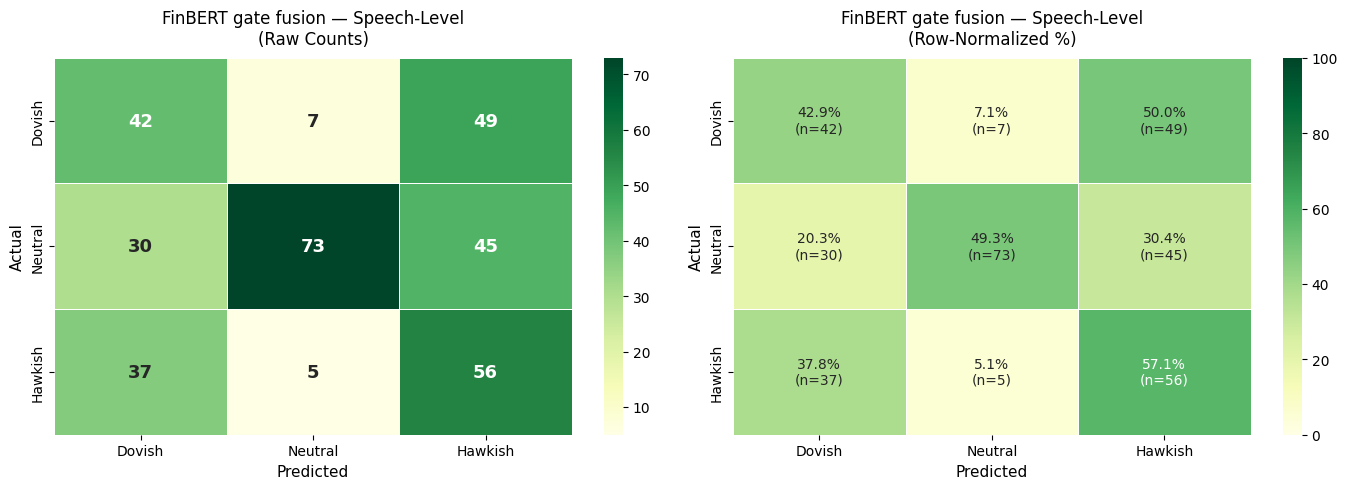

✅ Saved: confusion_matrix.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

# ── Confusion Matrix — Speech-Level ──────────────────────────────
def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)

    # Normalize for percentages
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    labels = ['Dovish', 'Neutral', 'Hawkish']
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ── Left: Raw counts ─────────────────────────────────────────
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlGn',
                xticklabels=labels, yticklabels=labels,
                linewidths=0.5, linecolor='white',
                ax=axes[0], cbar=True,
                annot_kws={"size": 13, "weight": "bold"})
    axes[0].set_title(f'{title}\n(Raw Counts)', fontsize=12, pad=10)
    axes[0].set_xlabel('Predicted', fontsize=11)
    axes[0].set_ylabel('Actual',    fontsize=11)

    # ── Right: Normalized % ──────────────────────────────────────
    annot_labels = np.array([
        [f"{cm_norm[i,j]:.1f}%\n(n={cm[i,j]})"
         for j in range(3)] for i in range(3)
    ])
    sns.heatmap(cm_norm, annot=annot_labels, fmt='', cmap='YlGn',
                xticklabels=labels, yticklabels=labels,
                vmin=0, vmax=100,
                linewidths=0.5, linecolor='white',
                ax=axes[1], cbar=True,
                annot_kws={"size": 10})
    axes[1].set_title(f'{title}\n(Row-Normalized %)', fontsize=12, pad=10)
    axes[1].set_xlabel('Predicted', fontsize=11)
    axes[1].set_ylabel('Actual',    fontsize=11)

    plt.tight_layout()
    plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Saved: confusion_matrix.png")

# ── Call karo apne best predictions pe ───────────────────────────
# Fine-tuned FinBERT (best_preds eval cell ke baad)
plot_confusion_matrix(test_labels_final, test_preds_final,
                      title="FinBERT gate fusion — Speech-Level")

# MLP pe bhi laga sakte ho:
# plot_confusion_matrix(best_mlp_true, best_mlp_preds,
#                       title="MLP on FinBERT Embeddings")

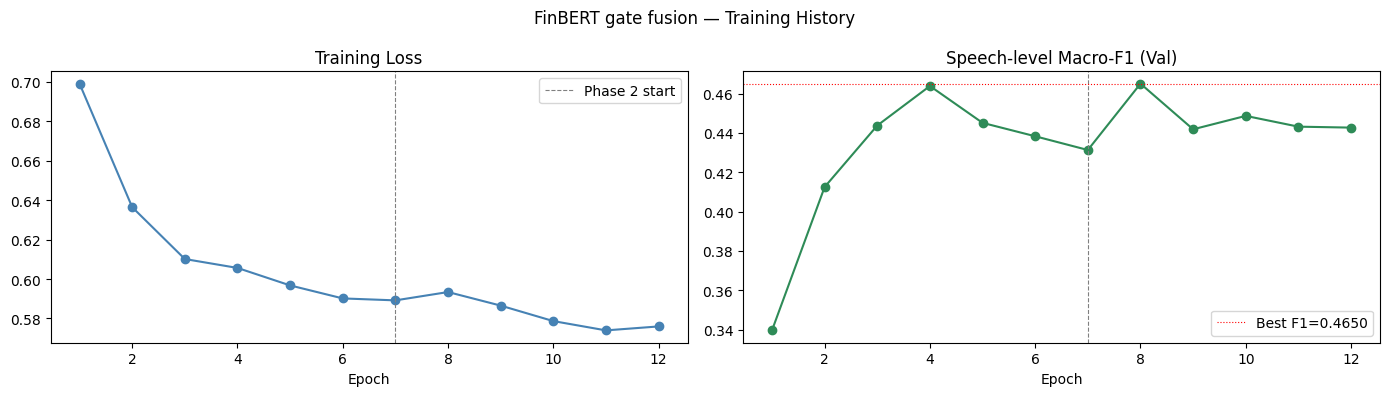

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ep = range(1, len(history['train_loss']) + 1)
axes[0].plot(ep, history['train_loss'], marker='o', color='steelblue')
axes[0].axvline(EPOCHS, color='gray', ls='--', lw=0.8, label='Phase 2 start')
axes[0].set_title('Training Loss'); axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(ep, history['val_f1'], marker='o', color='seagreen')
axes[1].axvline(EPOCHS, color='gray', ls='--', lw=0.8)
axes[1].axhline(best_f1, color='red', ls=':', lw=0.8, label=f'Best F1={best_f1:.4f}')
axes[1].set_title('Speech-level Macro-F1 (Val)'); axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.suptitle('FinBERT gate fusion — Training History', fontsize=12)
plt.tight_layout(); plt.show()

KeyError: 'test_loss'

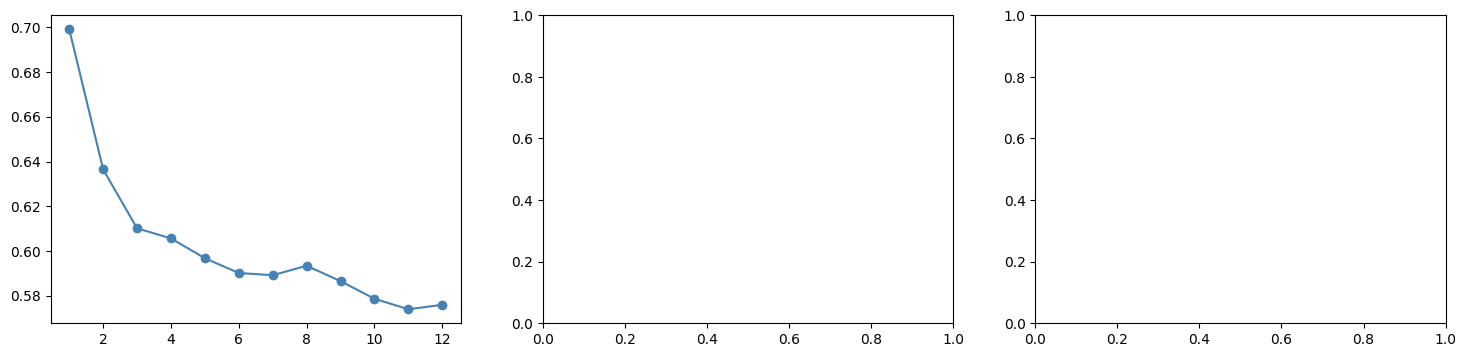

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

ep = range(1, len(history['train_loss']) + 1)

# Train Loss
axes[0].plot(ep, history['train_loss'], marker='o', color='steelblue', label='Train Loss')
axes[0].plot(ep, history['test_loss'], marker='s', color='orange', label='Test Loss')
axes[0].axvline(EPOCHS, color='gray', ls='--', lw=0.8, label='Phase 2 start')
axes[0].set_title('Loss Comparison')
axes[0].set_xlabel('Epoch')
axes[0].legend()

# Validation F1
axes[1].plot(ep, history['val_f1'], marker='o', color='seagreen', label='Validation F1')
axes[1].axvline(EPOCHS, color='gray', ls='--', lw=0.8)
axes[1].axhline(best_f1, color='red', ls=':', lw=0.8, label=f'Best Val F1={best_f1:.4f}')
axes[1].set_title('Validation Macro-F1')
axes[1].set_xlabel('Epoch')
axes[1].legend()

# Test F1
axes[2].plot(ep, history['test_f1'], marker='o', color='purple', label='Test F1')
axes[2].axvline(EPOCHS, color='gray', ls='--', lw=0.8)
axes[2].set_title('Test Macro-F1')
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.suptitle('FinBERT Gate Fusion — Training / Validation / Test History', fontsize=12)
plt.tight_layout()
plt.show()

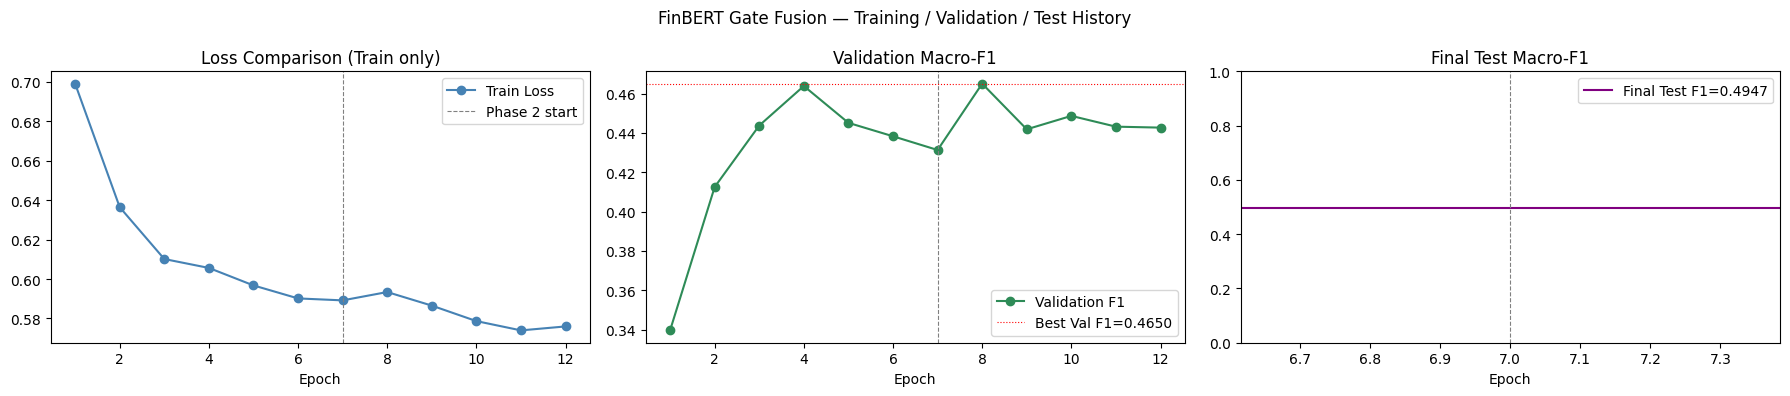

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

ep = range(1, len(history['train_loss']) + 1)

# Train Loss
axes[0].plot(ep, history['train_loss'], marker='o', color='steelblue', label='Train Loss')
# Removed: axes[0].plot(ep, history['test_loss'], marker='s', color='orange', label='Test Loss')
axes[0].axvline(EPOCHS, color='gray', ls='--', lw=0.8, label='Phase 2 start')
axes[0].set_title('Loss Comparison (Train only)')
axes[0].set_xlabel('Epoch')
axes[0].legend()

# Validation F1
axes[1].plot(ep, history['val_f1'], marker='o', color='seagreen', label='Validation F1')
axes[1].axvline(EPOCHS, color='gray', ls='--', lw=0.8)
axes[1].axhline(best_f1, color='red', ls=':', lw=0.8, label=f'Best Val F1={best_f1:.4f}')
axes[1].set_title('Validation Macro-F1')
axes[1].set_xlabel('Epoch')
axes[1].legend()

# Test F1 (using final test_f1_final from evaluation)
# Assuming test_f1_final is available from previous cell execution
if 'test_f1_final' in globals():
    axes[2].axhline(test_f1_final, color='purple', ls='-', lw=1.5, label=f'Final Test F1={test_f1_final:.4f}')
    axes[2].set_title('Final Test Macro-F1')
else:
    axes[2].set_title('Test Macro-F1 (Data N/A)')

axes[2].axvline(EPOCHS, color='gray', ls='--', lw=0.8)
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.suptitle('FinBERT Gate Fusion — Training / Validation / Test History', fontsize=12)
plt.tight_layout()
plt.show()

finbert+LR

In [ ]:
print(type(model.bert))
print(next(model.bert.parameters()).device)

<class 'transformers.models.bert.modeling_bert.BertModel'>
cuda:0


In [ ]:
# ════════════════════════════════════════════════════════════════
# FEATURE COMPARISON — All Models × All Feature Combinations
#
# Feature sets:
#   A) LM only         (5-dim)
#   B) LM + Bond       (5+3 = 8-dim)
#   C) BERT only       (768-dim)
#   D) BERT + Bond     (768+3 = 771-dim)
#   E) BERT + LM + Bond(768+5+3 = 776-dim)  ← most complete
#
# Classifiers: LR, RF, XGBoost, SVM, MLP
# ════════════════════════════════════════════════════════════════

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
import torch.nn as nn

# ── Step 1: Extract FinBERT [CLS] embeddings ─────────────────────
def extract_cls_embeddings(texts, tokenizer, bert_model, device,
                            batch_size=32):
    """Extract [CLS] token from frozen FinBERT for all speeches."""
    bert_model.eval()
    all_emb = []

    for i in range(0, len(texts), batch_size):
        batch_texts = list(texts[i:i+batch_size])
        enc = tokenizer(batch_texts, max_length=512, truncation=True,
                        padding=True, return_tensors='pt')
        input_ids      = enc['input_ids'].to(device)
        attention_mask = enc['attention_mask'].to(device)

        with torch.no_grad():
            hidden = bert_model(
                input_ids=input_ids,
                attention_mask=attention_mask
            ).last_hidden_state
            cls_emb = hidden[:, 0, :]   # [CLS] token

        all_emb.append(cls_emb.cpu().float().numpy())

        if (i // batch_size) % 10 == 0:
            print(f"  {i+len(batch_texts)}/{len(texts)} done...")

    return np.vstack(all_emb)


print("Extracting FinBERT [CLS] embeddings...")
print("  Train set:")
train_bert_emb = extract_cls_embeddings(
    train_texts, tokenizer, model.bert, device)
print("  Val set:")
val_bert_emb   = extract_cls_embeddings(
    val_texts, tokenizer, model.bert, device)
print("  Test set:")
test_bert_emb  = extract_cls_embeddings(
    test_texts, tokenizer, model.bert, device)

print(f"\n✅ BERT embeddings extracted")
print(f"   Train: {train_bert_emb.shape}")
print(f"   Val  : {val_bert_emb.shape}")
print(f"   Test : {test_bert_emb.shape}")

Extracting FinBERT [CLS] embeddings...
  Train set:
  32/1603 done...
  352/1603 done...
  672/1603 done...
  992/1603 done...
  1312/1603 done...
  1603/1603 done...
  Val set:
  32/344 done...
  344/344 done...
  Test set:
  32/344 done...
  344/344 done...

✅ BERT embeddings extracted
   Train: (1603, 768)
   Val  : (344, 768)
   Test : (344, 768)


In [ ]:
# ── Step 2: Build Feature Matrices ───────────────────────────────
# Raw LM features (already normalized: train_lm_feats etc.)
# Raw temporal features (already normalized: train_temporal etc.)

# Normalize BERT embeddings (fit on train only)
bert_scaler    = StandardScaler().fit(train_bert_emb)
train_bert_sc  = bert_scaler.transform(train_bert_emb).astype(np.float32)
val_bert_sc    = bert_scaler.transform(val_bert_emb).astype(np.float32)
test_bert_sc   = bert_scaler.transform(test_bert_emb).astype(np.float32)

# Define test_temporal, assuming TEMPORAL_COLS and temporal_scaler are available from previous cells
test_temporal = df.iloc[test_idx][TEMPORAL_COLS].values.astype(np.float32)
test_temporal = temporal_scaler.transform(test_temporal)

# Feature sets dictionary
FEATURE_SETS = {
    "A) LM only (5-dim)": {
        "train": train_lm_feats,
        "val":   val_lm_feats,
        "test":  test_lm_feats,
    },
    "B) LM + Bond (8-dim)": {
        "train": np.hstack([train_lm_feats, train_temporal]),
        "val":   np.hstack([val_lm_feats,   val_temporal]),
        "test":  np.hstack([test_lm_feats,  test_temporal]),
    },
    "C) BERT only (768-dim)": {
        "train": train_bert_sc,
        "val":   val_bert_sc,
        "test":  test_bert_sc,
    },
    "D) BERT + Bond (771-dim)": {
        "train": np.hstack([train_bert_sc, train_temporal]),
        "val":   np.hstack([val_bert_sc,   val_temporal]),
        "test":  np.hstack([test_bert_sc,  test_temporal]),
    },
    "E) BERT + LM + Bond (776-dim)": {
        "train": np.hstack([train_bert_sc, train_lm_feats, train_temporal]),
        "val":   np.hstack([val_bert_sc,   val_lm_feats,   val_temporal]),
        "test":  np.hstack([test_bert_sc,  test_lm_feats,  test_temporal]),
    },
}

print("Feature sets ready:")
for name, fs in FEATURE_SETS.items():
    print(f"  {name}: train={fs['train'].shape}")

Feature sets ready:
  A) LM only (5-dim): train=(1603, 5)
  B) LM + Bond (8-dim): train=(1603, 8)
  C) BERT only (768-dim): train=(1603, 768)
  D) BERT + Bond (771-dim): train=(1603, 771)
  E) BERT + LM + Bond (776-dim): train=(1603, 776)


In [ ]:
# ── Step 3: MLP Classifier definition ────────────────────────────
class SimpleMLPClassifier(nn.Module):
    def __init__(self, input_dim, n_classes=3):
        super().__init__()
        h = min(256, max(64, input_dim // 3))
        self.net = nn.Sequential(
            nn.Linear(input_dim, h), nn.LayerNorm(h),
            nn.GELU(), nn.Dropout(0.3),
            nn.Linear(h, 64), nn.LayerNorm(64),
            nn.GELU(), nn.Dropout(0.2),
            nn.Linear(64, n_classes)
        )
    def forward(self, x):
        return self.net(x)


def train_mlp(X_tr, y_tr, X_va, y_va, cw, epochs=30):
    """Train simple MLP on tabular features."""
    ds_tr = torch.utils.data.TensorDataset(
        torch.tensor(X_tr, dtype=torch.float32),
        torch.tensor(y_tr, dtype=torch.long))
    loader = torch.utils.data.DataLoader(
        ds_tr, batch_size=32, shuffle=True)

    m     = SimpleMLPClassifier(X_tr.shape[1]).to(device)
    crit  = FocalLoss(weight=cw, gamma=2.0, smoothing=0.1)
    opt   = torch.optim.AdamW(m.parameters(), lr=1e-3, weight_decay=0.01)
    best  = 0.0
    state = None

    for ep in range(epochs):
        m.train()
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            loss = crit(m(xb), yb).mean()
            opt.zero_grad(); loss.backward(); opt.step()
        m.eval()
        with torch.no_grad():
            logits = m(torch.tensor(X_va, dtype=torch.float32).to(device))
            preds  = torch.argmax(logits, 1).cpu().numpy()
        f1 = f1_score(y_va, preds, average='macro', zero_division=0)
        if f1 > best:
            best  = f1
            state = {k: v.clone() for k,v in m.state_dict().items()}

    m.load_state_dict(state)
    return m, best


print("✅ MLP trainer ready")

✅ MLP trainer ready


In [ ]:
# ── Step 4: Run All Experiments ──────────────────────────────────
from sklearn.utils.class_weight import compute_class_weight

cw_np = compute_class_weight('balanced',
        classes=np.array([0,1,2]), y=train_labels)
cw_np[0] *= 1.25; cw_np[2] *= 1.25
cw_tensor = torch.tensor(cw_np, dtype=torch.float, device=device)
sample_weight = np.array([cw_np[l] for l in train_labels])

# Store results: results[feature_set][classifier] = (val_f1, test_f1)
all_results = {}

for feat_name, fs in FEATURE_SETS.items():
    print(f"\n{'='*60}")
    print(f"Feature Set: {feat_name}")
    print(f"{'='*60}")

    X_tr  = fs['train']
    X_val = fs['val']
    X_te  = fs['test']
    all_results[feat_name] = {}

    # ── Logistic Regression ──────────────────────────────────
    print("  Running LR...", end="")
    clf = LogisticRegression(max_iter=1000,
          class_weight='balanced', C=1.0, random_state=42)
    clf.fit(X_tr, train_labels)
    vf = f1_score(val_labels,  clf.predict(X_val), average='macro')
    tf = f1_score(test_labels, clf.predict(X_te),  average='macro')
    all_results[feat_name]['Logistic Regression'] = (vf, tf)
    print(f"  Val={vf:.4f}  Test={tf:.4f}")

    # ── Random Forest ────────────────────────────────────────
    print("  Running RF...", end="")
    clf = RandomForestClassifier(n_estimators=500, max_depth=20,
          min_samples_leaf=2, class_weight='balanced',
          random_state=42, n_jobs=-1)
    clf.fit(X_tr, train_labels)
    vf = f1_score(val_labels,  clf.predict(X_val), average='macro')
    tf = f1_score(test_labels, clf.predict(X_te),  average='macro')
    all_results[feat_name]['Random Forest'] = (vf, tf)
    print(f"  Val={vf:.4f}  Test={tf:.4f}")

    # ── XGBoost ──────────────────────────────────────────────
    print("  Running XGBoost...", end="")
    clf = XGBClassifier(n_estimators=300, max_depth=6,
          learning_rate=0.05, subsample=0.8,
          colsample_bytree=0.8, eval_metric='mlogloss',
          random_state=42, n_jobs=-1, verbosity=0)
    clf.fit(X_tr, train_labels, sample_weight=sample_weight)
    vf = f1_score(val_labels,  clf.predict(X_val), average='macro')
    tf = f1_score(test_labels, clf.predict(X_te),  average='macro')
    all_results[feat_name]['XGBoost'] = (vf, tf)
    print(f"  Val={vf:.4f}  Test={tf:.4f}")

    # ── SVM ──────────────────────────────────────────────────
    print("  Running SVM...", end="")
    clf = SVC(kernel='rbf', C=10.0, gamma='scale',
              class_weight='balanced', random_state=42)
    clf.fit(X_tr, train_labels)
    vf = f1_score(val_labels,  clf.predict(X_val), average='macro')
    tf = f1_score(test_labels, clf.predict(X_te),  average='macro')
    all_results[feat_name]['SVM'] = (vf, tf)
    print(f"  Val={vf:.4f}  Test={tf:.4f}")

    # ── MLP ──────────────────────────────────────────────────
    print("  Running MLP...", end="")
    mlp_m, vf = train_mlp(X_tr, train_labels, X_val, val_labels,
                           cw_tensor, epochs=30)
    mlp_m.eval()
    with torch.no_grad():
        preds = torch.argmax(
            mlp_m(torch.tensor(X_te, dtype=torch.float32).to(device)),
            1).cpu().numpy()
    tf = f1_score(test_labels, preds, average='macro', zero_division=0)
    all_results[feat_name]['MLP'] = (vf, tf)
    print(f"  Val={vf:.4f}  Test={tf:.4f}")

print("\n✅ All experiments complete!")


Feature Set: A) LM only (5-dim)
  Running LR...  Val=0.3481  Test=0.3985
  Running RF...  Val=0.3888  Test=0.3907
  Running XGBoost...  Val=0.3841  Test=0.3952
  Running SVM...  Val=0.3192  Test=0.4023
  Running MLP...  Val=0.2948  Test=0.3411

Feature Set: B) LM + Bond (8-dim)
  Running LR...  Val=0.4255  Test=0.4551
  Running RF...  Val=0.4570  Test=0.4583
  Running XGBoost...  Val=0.4245  Test=0.4687
  Running SVM...  Val=0.4937  Test=0.4892
  Running MLP...  Val=0.4890  Test=0.4983

Feature Set: C) BERT only (768-dim)
  Running LR...  Val=0.4300  Test=0.4310
  Running RF...  Val=0.3652  Test=0.3610
  Running XGBoost...  Val=0.4474  Test=0.3498
  Running SVM...  Val=0.4289  Test=0.3737
  Running MLP...  Val=0.4378  Test=0.3705

Feature Set: D) BERT + Bond (771-dim)
  Running LR...  Val=0.4705  Test=0.4327
  Running RF...  Val=0.4350  Test=0.3879
  Running XGBoost...  Val=0.4698  Test=0.4336
  Running SVM...  Val=0.4523  Test=0.4128
  Running MLP...  Val=0.4840  Test=0.4361

Feature

In [ ]:
# ── Step 5: Print Complete Comparison Table ───────────────────────
classifiers = ['Logistic Regression','Random Forest',
               'XGBoost','SVM','MLP']

print(f"\n{'='*90}")
print(f"  COMPLETE COMPARISON — Feature Set × Classifier (Test Macro-F1)")
print(f"{'='*90}")

# Header
header = f"  {'Classifier':<22}"
for feat in FEATURE_SETS:
    short = feat.split(")")[0] + ")"   # e.g. "A)"
    header += f" {short:>9}"
print(header)
print(f"  {'-'*88}")

# Rows
for clf_name in classifiers:
    row = f"  {clf_name:<22}"
    for feat in FEATURE_SETS:
        vf, tf = all_results[feat][clf_name]
        row += f"  {tf:>7.4f}"
    print(row)

print(f"  {'-'*88}")
print(f"  {'Best per feature set:':<22}", end="")
for feat in FEATURE_SETS:
    best_tf = max(all_results[feat][c][1] for c in classifiers)
    print(f"  {best_tf:>7.4f}", end="")
print()

# Add FinBERTHybrid v15 as final row
print(f"\n  {'FinBERTHybrid v15':<22}  {'n/a':>7}  {'n/a':>7}  {'n/a':>7}  {'n/a':>7}  {test_f1_final:>7.4f}  ← FINAL")
print(f"{'='*90}")
print()
print("Feature sets:")
for k in FEATURE_SETS:
    print(f"  {k}")


  COMPLETE COMPARISON — Feature Set × Classifier (Test Macro-F1)
  Classifier                    A)        B)        C)        D)        E)
  ----------------------------------------------------------------------------------------
  Logistic Regression      0.3985   0.4551   0.4310   0.4327   0.4412
  Random Forest            0.3907   0.4583   0.3610   0.3879   0.3724
  XGBoost                  0.3952   0.4687   0.3498   0.4336   0.4531
  SVM                      0.4023   0.4892   0.3737   0.4128   0.4126
  MLP                      0.3531   0.4965   0.3855   0.4346   0.4309
  ----------------------------------------------------------------------------------------
  Best per feature set:    0.4023   0.4965   0.4310   0.4346   0.4531

  FinBERTHybrid v15           n/a      n/a      n/a      n/a   0.4947  ← FINAL

Feature sets:
  A) LM only (5-dim)
  B) LM + Bond (8-dim)
  C) BERT only (768-dim)
  D) BERT + Bond (771-dim)
  E) BERT + LM + Bond (776-dim)


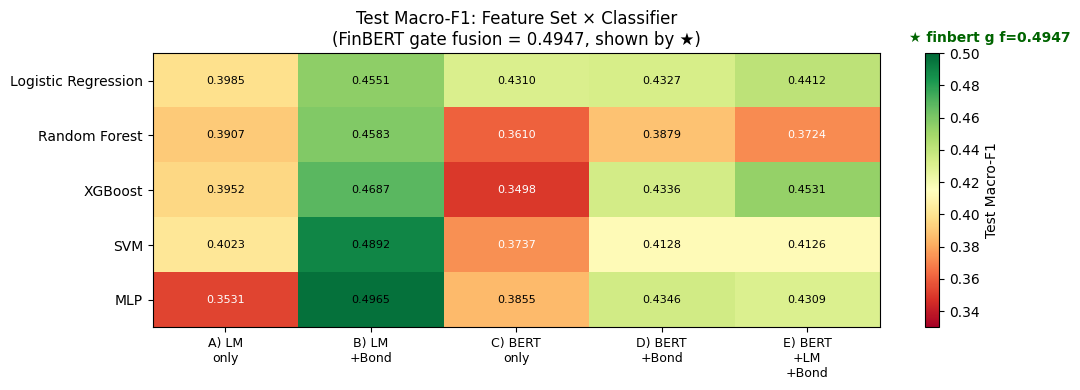

✅ Heatmap saved as feature_comparison_heatmap.png


In [ ]:
# ── Step 6: Heatmap Visualization ────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

feat_labels = ["A) LM\nonly", "B) LM\n+Bond", "C) BERT\nonly",
               "D) BERT\n+Bond", "E) BERT\n+LM\n+Bond"]

data = np.array([
    [all_results[f][c][1] for f in FEATURE_SETS]
    for c in classifiers
])

fig, ax = plt.subplots(figsize=(11, 4))
im = ax.imshow(data, cmap='RdYlGn', vmin=0.33, vmax=0.50,
               aspect='auto')
plt.colorbar(im, ax=ax, label='Test Macro-F1')

ax.set_xticks(range(len(FEATURE_SETS)))
ax.set_xticklabels(feat_labels, fontsize=9)
ax.set_yticks(range(len(classifiers)))
ax.set_yticklabels(classifiers, fontsize=10)
ax.set_title("Test Macro-F1: Feature Set × Classifier\n"
             "(FinBERT gate fusion = 0.4947, shown by ★)",
             fontsize=12)

for i in range(len(classifiers)):
    for j in range(len(FEATURE_SETS)):
        ax.text(j, i, f"{data[i,j]:.4f}", ha='center',
                va='center', fontsize=8,
                color='white' if data[i,j] < 0.38 else 'black')

# Mark FinBERT v15
ax.text(4.7, -0.7, "★ finbert g f=0.4947", fontsize=10,
        color='darkgreen', fontweight='bold')

plt.tight_layout()
plt.savefig('feature_comparison_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Heatmap saved as feature_comparison_heatmap.png")